# Surface-Frame Stiffness Analysis (flat-surface-follow)

Interprets the **impedance stiffness** the policy applies while tracking a flat
surface, resolved onto the **surface frame** — the phaseless, surface-following
analogue of `stiff_rot_analysis` (which splits a peg insertion by task phase).

The flat-surface-follow task has **no phases** (`free_space` -> `search` ->
`insertion`): the tool is in contact tracking the surface for the whole episode, so
every metric is a single end-of-training value. The natural reference frame is the
**surface frame** `[along-track, cross-track, normal]`, not the peg axis. The applied
translational stiffness `K` resolved onto those axes is logged by
`wrappers/controllers/ctrl_action_interface.py::_log_stiffness_frame_metrics` as
`diag(R_surfᵀ K R_surf)`:

* **k_normal** (k$_n$) — stiffness along the surface **normal** (the vertical
  into-surface axis); how hard the policy presses down / resists penetration.
* **k_along_track** (k$_\parallel$) — stiffness **along** the path direction.
* **k_cross_track** (k$_\perp$) — in-plane **lateral** stiffness (across the path).

An isotropic baseline (Fixed) reads ~equal in all three; the rotated / GAS modes
shape the three directions differently.

**Ovals:** the stiffness-oval cartoon is inherently 2-D, so each oval shows only two
directions — the **normal (vertical axis)** and **along-track (horizontal)** — with
cross-track dropped. Round = isotropic, tall = stiff-normal / compliant-along.

Loading lives in `data_loader.py`; plotting in `plot_tools.py`. This notebook only
sets parameters and renders outputs.


## 1. Imports

In [25]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# The utility modules (data_loader.py, plot_tools.py) live next to this notebook
# in data_analysis/. Make them importable whether the kernel starts in
# data_analysis/ or the repo root by walking up from the cwd to find them.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (os.path.join(d, "data_analysis"), d):
            if os.path.isfile(os.path.join(cand, "data_loader.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import importlib
import data_loader as dl   # data loading + reduction (single source of truth)
import plot_tools as pt    # plotting + styling (single source of truth)

# Force a fresh load from disk every time this cell runs, so edits to data_loader.py /
# plot_tools.py (display names, colors, loaders) take effect WITHOUT restarting the kernel.
# Reload data_loader FIRST — plot_tools imports it, so it must re-bind the updated module.
importlib.reload(dl)
importlib.reload(pt)

<module 'plot_tools' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/plot_tools.py'>

## 2. Global parameters

Folder, surface-direction specs, reduction, output folder, and the shared `STYLE` object.

In [ ]:
# Root folder that contains the experiment-group sub-folders (runs/{FOLDER_NAME}).
PROJECT_ROOT = dl.find_project_root()
RUNS_ROOT = dl.runs_root()
# --- Data source. Set WANDB_PROJECT + WANDB_TAG to pull runs from Weights & Biases:
# downloaded ONCE into runs/{WANDB_PROJECT}_{WANDB_TAG}/ (cached — the load cell below skips
# groups already present, so this notebook AND the other surface notebooks reuse the same data).
# Set WANDB_PROJECT/WANDB_TAG = None to load a local LOCAL_FOLDER instead.
WANDB_PROJECT = "surface_baselines"
WANDB_TAG     = "high-ent_high-gain"
WANDB_ENTITY  = "hur"
LOCAL_FOLDER  = "baseline_swap"  # used only when WANDB_PROJECT/TAG are None
FOLDER_NAME   = f"{WANDB_PROJECT}_{WANDB_TAG}" if (WANDB_PROJECT and WANDB_TAG) else LOCAL_FOLDER
# Force a FRESH pull from the wandb server, overwriting the local cache even if it looks
# complete (ignores the download-once cache). Leave False for the fast cached path; flip True
# to grab the latest data after runs have logged more (used by the load cell below).
FORCE_WANDB_REFRESH = True

# Confidence band: mean +/- CI_Z * SEM across runs. 1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per group (ranked by peak success); -1 keeps all.
TOP_N = -1
SUCCESS_METRIC = "Episode / Ever success rate"

# Shared x-axis for time-series plots. XLIM is (min, max) or None.
XLABEL = "Env Steps"
XLIM = (0, 100149)

# The flat-surface-follow task has NO free_space -> search -> insertion phases (the
# tool tracks a surface the whole episode), so there is nothing to split on — unlike
# the peg notebook, every metric here is a single end-of-training value. The natural
# reference frame is the SURFACE frame [along-track, cross-track, normal] rather than
# the peg axis; the applied stiffness resolved onto those axes is logged as
# Impedance_Stiffness/k_{along_track,cross_track,normal}_mean (see
# ctrl_action_interface._log_stiffness_frame_metrics). NORMAL is the vertical
# into-surface axis; ALONG-TRACK follows the path; CROSS-TRACK is the in-plane lateral.
SURF = pt.SURFACE_STIFFNESS_TAGS   # {"along_track","cross_track","normal"} -> tag
DIR_SPECS = [
    {"key": "normal",      "tag": SURF["normal"],      "label": "k$_n$ (normal / into-surface)"},
    {"key": "along_track", "tag": SURF["along_track"], "label": "k$_\\parallel$ (along-track)"},
    {"key": "cross_track", "tag": SURF["cross_track"], "label": "k$_\\perp$ (cross-track)"},
]

# How each scalar is reduced per run before aggregating across runs.
# "mean_tail" averages the last few logged points (denoises the converged value);
# alternatives: "last", "at_best" (value at the run's peak-success step), "max".
REDUCE = "at_best"

# Dated output folder: runs/{FOLDER_NAME}/plots_stiffsurf_{date}/{name}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_stiffsurf_{datetime.now().strftime('%Y%m%d')}")

# Styling/context. Display names + colors default to the surface controller ladder
# (Fixed / VICES / GAS variants); see plot_tools.PlotStyle.
STYLE = pt.PlotStyle(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)
STEP_CEILING = STYLE.step_ceiling

## 3. Load data

In [ ]:
# Pull from wandb into runs/{FOLDER_NAME}/ (download once; cached). No-op for a local FOLDER_NAME.
# FORCE_WANDB_REFRESH=True re-fetches every group from the server and overwrites the local cache.
if WANDB_PROJECT and WANDB_TAG:
    dl.download_wandb_data(WANDB_PROJECT, WANDB_TAG, entity=WANDB_ENTITY, root=RUNS_ROOT,
                           force=FORCE_WANDB_REFRESH)
DATA = dl.load_data(FOLDER_NAME, RUNS_ROOT)
DATA = dl.filter_top_n(DATA, TOP_N, SUCCESS_METRIC, STEP_CEILING)

# Confirm the surface-frame stiffness family is present in the loaded runs.
_tags = sorted({t for run in next(iter(DATA.values())) for t in run})
print("surface-frame stiffness tags:",
      [t for t in _tags if "Impedance_Stiffness/k_" in t and t.endswith("_mean")])

## 4. Directional stiffness table

End-of-training surface-frame stiffness per controller (normal / along-track / cross-track).

In [28]:
# End-of-training surface-frame stiffness table. For each controller, the applied
# translational stiffness resolved onto the three SURFACE directions (normal /
# along-track / cross-track), reduced with REDUCE, mean +/- 95% CI across runs.
# These are descriptive (how the policy shapes its compliance), not better/worse,
# so nothing is bolded. An isotropic baseline (Fixed) reads ~equal in all three.
# selection_metric=SUCCESS_METRIC is required by reduce="at_best" (value at each run's
# peak-success step) and harmlessly ignored by the other reduces.
print(f"Surface-frame stiffness by direction (reduce={REDUCE})\n")
hdr = ["controller"] + [s["label"].replace("$", "").replace("\\", "") for s in DIR_SPECS]
print("  ".join(f"{h:>28}" for h in hdr))
summaries = {s["key"]: dl.summarize_tag(DATA, s["tag"], reduce=REDUCE, ci_z=CI_Z,
                                        step_ceiling=STEP_CEILING,
                                        selection_metric=SUCCESS_METRIC) for s in DIR_SPECS}
for group in DATA:
    cells = [STYLE.name(group)]
    for s in DIR_SPECS:
        st = summaries[s["key"]]
        cells.append(f"{st[group][0]:.1f} +/- {st[group][1]:.1f}" if group in st else "--")
    print("  ".join(f"{c:>28}" for c in cells))

Surface-frame stiffness by direction (reduce=at_best)

                  controller   k_n (normal / into-surface)      k_parallel (along-track)          k_perp (cross-track)
                       Fixed                 650.0 +/- 0.0                 650.0 +/- 0.0                 650.0 +/- 0.0
                       VICES                808.3 +/- 21.8                 719.1 +/- 5.2                 698.5 +/- 7.2
           Ours (GT Geo-Rot)                 700.8 +/- 3.7                 714.1 +/- 4.8                 685.2 +/- 3.2
           Ours (GT Dyn-Rot)                756.5 +/- 12.3                698.6 +/- 11.7                 685.8 +/- 4.2
             Ours (Dyn-Loss)                729.4 +/- 44.3                730.7 +/- 25.3                707.2 +/- 19.7
             Ours (Geo-Loss)                742.7 +/- 15.9                703.7 +/- 10.1                 693.4 +/- 3.1


## 5. Directional stiffness over training

One facet per surface direction; the main diagnostic for *when* each direction is shaped.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_stiffness_by_direction.svg


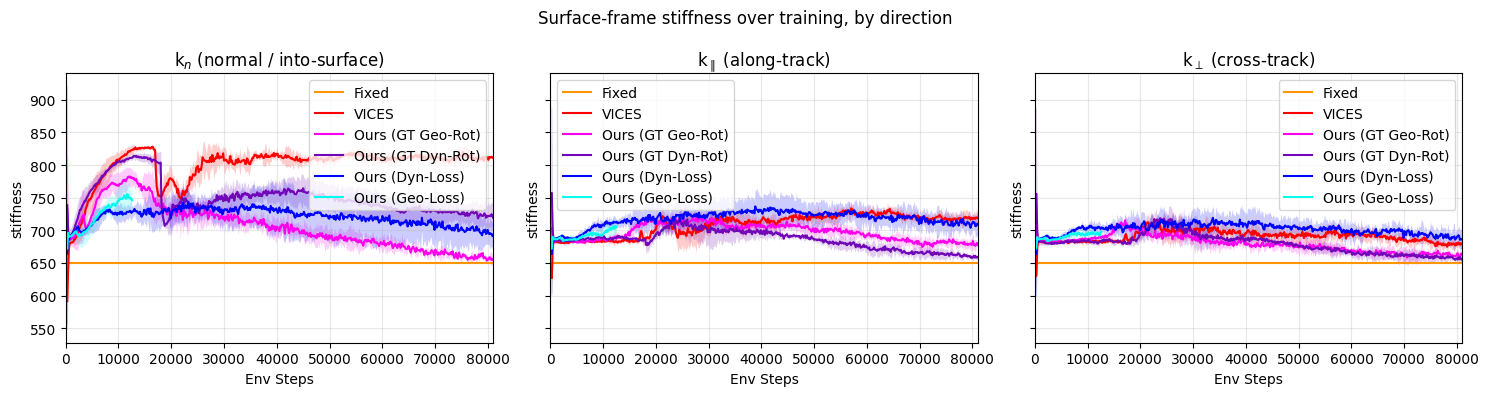

In [29]:
# (1) Directional stiffness over training — one facet per surface direction
# (normal / along-track / cross-track). Answers "did the policy LEARN to shape its
# compliance per direction, and when in training?". One mean+CI line per controller.
fig, axes = plt.subplots(1, len(DIR_SPECS), figsize=(5 * len(DIR_SPECS), 4), sharey=True)
for ax, s in zip(axes, DIR_SPECS):
    pt.plot_metric(DATA, s["tag"], "stiffness", s["label"], STYLE, ax=ax,
                   legend_loc="best")
    ax.set_title(s["label"])
fig.suptitle("Surface-frame stiffness over training, by direction")
fig.tight_layout()
pt.save_plot(fig, "surface_stiffness_by_direction", STYLE)
plt.show()

## 6. k$_n$ vs k$_\parallel$ scatter

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_normal_vs_along.svg


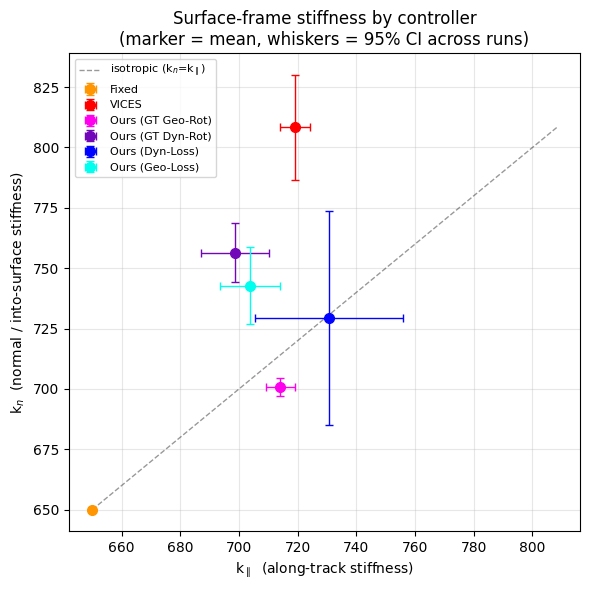

In [30]:
# (2) k_normal vs k_along_track scatter — one marker (mean +/- 95% CI) per
# controller, reduced end-of-training. The y = x line is isotropy: ABOVE it the
# policy presses harder INTO the surface than it resists ALONG the path (typical
# surface-following compliance), BELOW it the reverse. Cross-track is omitted here
# so the plane reads as normal-vs-tangent; see the table/curves for cross-track.
# selection_metric=SUCCESS_METRIC lets reduce="at_best" read each run at its peak-success step.
ax = pt.plot_surface_stiffness_scatter(DATA, STYLE, reduce=REDUCE,
                                       selection_metric=SUCCESS_METRIC)
ax.figure.tight_layout()
pt.save_plot(ax.figure, "surface_normal_vs_along", STYLE)
plt.show()

## 7. Stiffness-oval cartoon (normal vs along-track)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_stiffness_ovals.svg


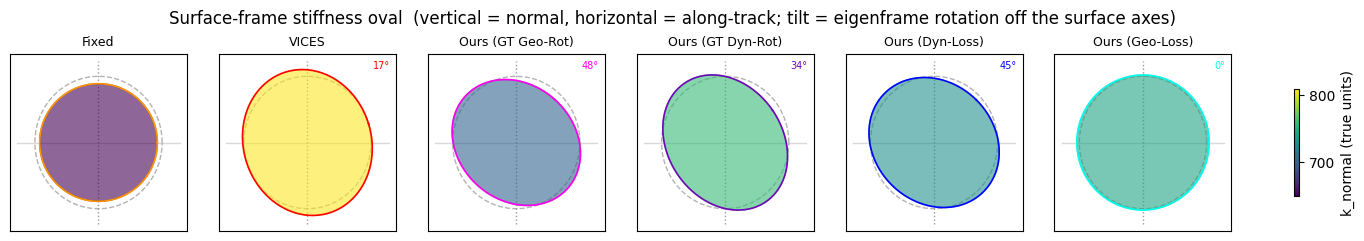

In [31]:
# (3) Stiffness-oval cartoon, one panel per controller. Each oval shows only TWO of
# the three surface directions — the surface NORMAL on the vertical axis and ALONG-TRACK
# horizontally; cross-track is dropped so the shape is a clean profile of "press-down vs.
# resist-along". The oval's semi-axes are the two principal stiffnesses of K in the
# (along, normal) plane and its TILT is the rotation of that eigenframe off the surface
# axes — RECONSTRUCTED from already-logged data (no re-run): the eigenvalues
# principal_{x,y,z} plus the surface diagonal (k_along, k_cross, k_normal). The eigenvalue
# nearest k_cross is the shared cross-track axis; the other two are the block eigenvalues
# λ± and the tilt off the normal is psi = 0.5*arccos((k_normal - k_along)/(λ+ - λ-)),
# in [0, 90] deg (|psi| only; left/right sign is cosmetic). No method authors K in the
# surface frame, so tilt != 0 means the stiffness eigenframe is rotated off [along, cross,
# normal]; isotropic (Fixed) stays a circle. The per-panel label shows the tilt angle.
#   COLOR_BY_NORMAL -> fill each oval by its TRUE k_normal via a shared colorbar.
#   SHOW_GHOST      -> draw the grand-mean (upright) oval (dashed grey) in every panel as a
#                      fixed anchor; each oval's deviation from it is the signal.
# selection_metric=SUCCESS_METRIC lets reduce="at_best" read each run at its peak-success step.
COLOR_BY_NORMAL = True
SHOW_GHOST = True
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE,
                                         selection_metric=SUCCESS_METRIC,
                                         color_by_normal=COLOR_BY_NORMAL, ghost=SHOW_GHOST)
pt.save_plot(fig, "surface_stiffness_ovals", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_stiffness_ovals_stretched.svg


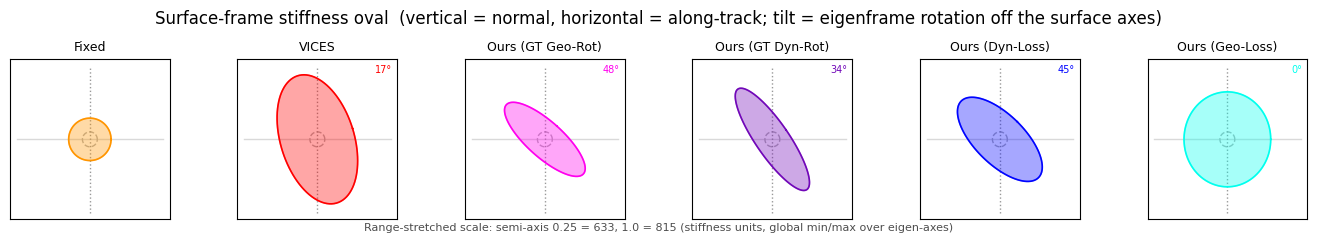

In [32]:
# (3a) Same ovals, range-stretched scale so small differences pop. Instead of
# dividing both semi-axes by the global MAX (which leaves every oval near full height
# when the directional stiffnesses only span a narrow band), scale_mode="range"
# affine-maps the global [min, max] over ALL semi-axis values (normal AND along-track
# pooled) onto [0.25, 1.0]. Same transform on both axes, so it stays relatively
# geometric while stretching the dynamic range. (Magnitudes are exaggerated; read
# shape/trend, not absolute size.) GHOST_NORMAL sets the reference oval radius in TRUE
# stiffness units, run through the same range map so it reads on the same scale.
SHOW_GHOST = True
GHOST_NORMAL = 600.0   # reference stiffness (true units); set to your anchor of choice
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE,
                                         selection_metric=SUCCESS_METRIC,
                                         scale_mode="range", ghost=SHOW_GHOST,
                                         ghost_normal=GHOST_NORMAL)
pt.save_plot(fig, "surface_stiffness_ovals_stretched", STYLE)
plt.show()

## 8. Stiffness-oval cartoon — normal-axis (z) tilt only

Same oval cartoon as §7, but the tilt shows ONLY the polar rotation of the method's
authored normal axis (`principal_z`) off the true surface normal — the tangential-plane
spin is dropped. `k_normal = ê_normalᵀ K ê_normal` is a Rayleigh quotient, so with the
tangential eigenvalues taken equal (`λ_t = mean(principal_x, principal_y)`) it inverts
exactly to `cos²θ = (k_normal − λ_t)/(principal_z − λ_t)`. This needs only `k_normal` +
the eigenvalues (not `k_along`) and drops the along-normal-plane assumption of §7, so it is
the cleaner/more exact answer to "how far is the pressing axis tilted off the surface?".
It is ill-conditioned (θ undefined → drawn upright) when `principal_z ≈ λ_t`, i.e. the
normal stiffness is barely distinguishable from the tangential — e.g. `Ours (GT Dyn-Rot)`.


saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_stiffness_ovals_ztilt.svg


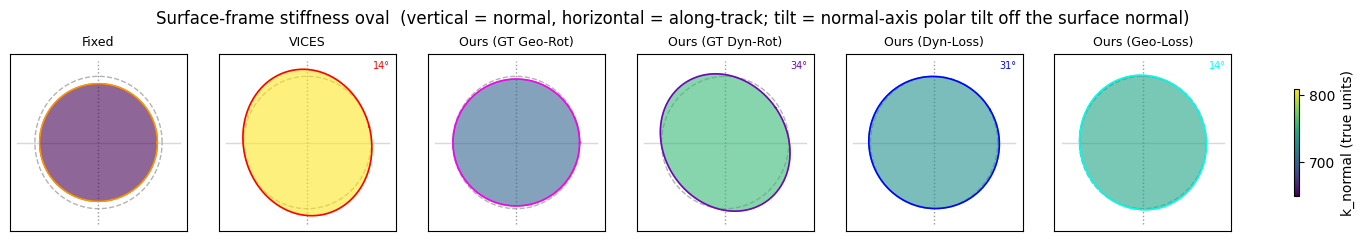

In [33]:
# (4) Normal-axis (z) tilt only. Identical oval cartoon to §7 (vertical = normal, horizontal
# = along-track; semi-axes = principal_z and the tangential mean), but tilt_mode="zaxis" draws
# ONLY the polar tilt theta of the authored normal axis off the TRUE surface normal:
#   cos^2(theta) = (k_normal - lam_t)/(principal_z - lam_t),  lam_t = mean(principal_x, principal_y).
# Exact under tangential isotropy; ignores tangential-plane spin. Ovals with principal_z ~ lam_t
# (normal indistinguishable from tangential) are ill-conditioned and drawn upright.
COLOR_BY_NORMAL = True
SHOW_GHOST = True
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE, tilt_mode="zaxis",
                                         selection_metric=SUCCESS_METRIC,
                                         color_by_normal=COLOR_BY_NORMAL, ghost=SHOW_GHOST)
pt.save_plot(fig, "surface_stiffness_ovals_ztilt", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_high-ent_high-gain/plots_stiffsurf_20260722/surface_stiffness_ovals_ztilt_stretched.svg


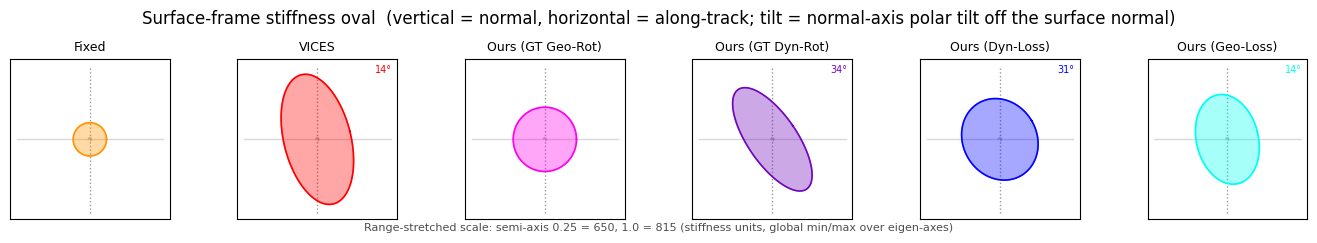

In [34]:
# (4a) Same normal-axis (z) tilt as (4), but range-stretched scale so small differences pop
# (identical scaling to (3a)): scale_mode="range" affine-maps the global [min, max] over all
# semi-axis values (principal_z AND the tangential mean, pooled) onto [0.25, 1.0]. Magnitudes
# are exaggerated — read shape/tilt, not absolute size. GHOST_NORMAL sets the reference oval
# radius in TRUE stiffness units, run through the same range map.
SHOW_GHOST = True
GHOST_NORMAL = 600.0   # reference stiffness (true units); set to your anchor of choice
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE, tilt_mode="zaxis",
                                         selection_metric=SUCCESS_METRIC,
                                         scale_mode="range", ghost=SHOW_GHOST,
                                         ghost_normal=GHOST_NORMAL)
pt.save_plot(fig, "surface_stiffness_ovals_ztilt_stretched", STYLE)
plt.show()